## Read data and plot images

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep +'GUI')[0]
if path not in sys.path:
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()
case = path.split(os.sep)[-1]
print(path, case)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
D:\Promotion\neurolib\GUI\current\gui\data\00121 00121


In [2]:
def set_target_init(exc_, inh_, max_I, model, dur):
    import neurolib.dashboard.functions as functions
    import numpy as np
    
    initVars_ = [None] * len(exc_)
    target_ = [None] * len(exc_)
    
    for i in range(len(exc_)):
        model.params.mue_ext_mean = exc_[i] * 5. 
        model.params.mui_ext_mean = inh_[i] * 5.

        model.params.duration = 3000.

        control0 = model.getZeroControl()
        control0 = functions.step_control(model, maxI_ = max_I[0])
        model.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = model.rates_exc[0,-1] 
        target_rates[1] = model.rates_inh[0,-1]

        control0 = functions.step_control(model, maxI_ = max_I[1])
        model.run(control=control0)
        
        state_vars = model.state_vars

        init_state_vars = np.zeros(( len(state_vars) ))
        for j in range(len(state_vars)):
            if model.state[state_vars[j]].size == 1:
                init_state_vars[j] = model.state[state_vars[j]][0]
            else:
                init_state_vars[j] = model.state[state_vars[j]][0,-1]

        initVars_[i] = init_state_vars

        model.params.duration = dur
        target_[i] = model.getZeroTarget()
        target_[i][:,0,:] = target_rates[0]
        target_[i][:,1,:] = target_rates[1]
    
    return initVars_, target_

In [3]:
data_array = data.read_data(aln, path, case)
exc_, inh_, both_c_, no_c_ = data_array[0:4]
exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

with open(path + os.sep + 'bi.pickle','rb') as f:
    load_array= pickle.load(f)
ext_exc = load_array[0]
ext_inh = load_array[1]

print(exc_)
print(inh_)

print(both_c_)
print(no_c_)

[bestControl_init, costnode_init, bestControl_0, bestState_0, costnode_0] = data.read_control(path, case)

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
dur_pre = 10
dur_post = 10

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.] 
    
path_directory = path.split(os.sep + 'data')[0] + os.sep + 'plots_' 
try:
    os.stat(path_directory)
except:
    os.mkdir(path_directory)
    
path_directory = path_directory + os.sep + case
try:
    os.stat(path_directory)
except:
    os.mkdir(path_directory)
    
cases_ = ['1', '2', '3', '4']
for c_dir in cases_:
    cases_dir = os.path.join(path_directory, c_dir)
    try:
        os.stat(cases_dir)
    except:
        os.mkdir(cases_dir)

[35, 45, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145]
[0, 5, 10, 15, 20, 25, 30, 40, 50]
[]
[]


D:\Promotion\neurolib\GUI\current\gui\plots_\00121\1
35


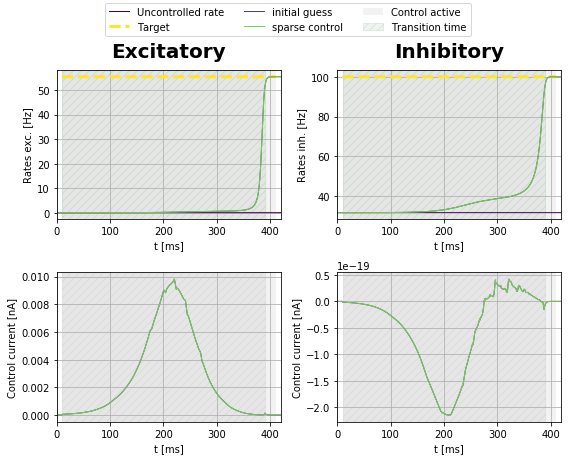

45


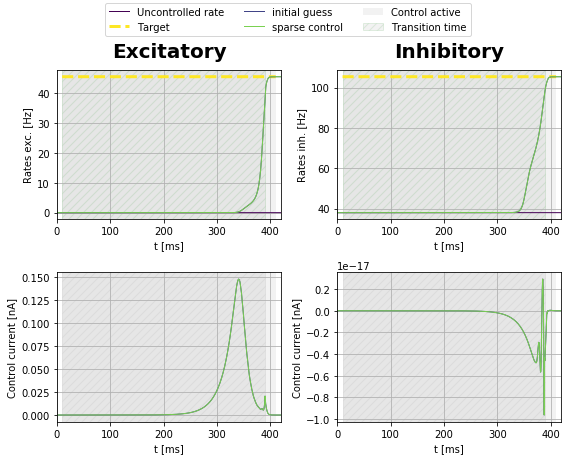

55


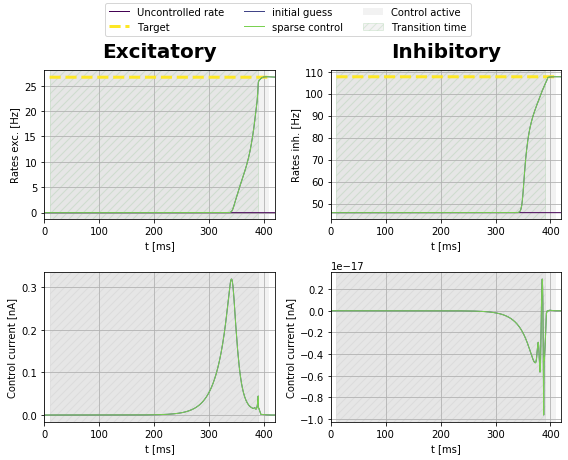

60


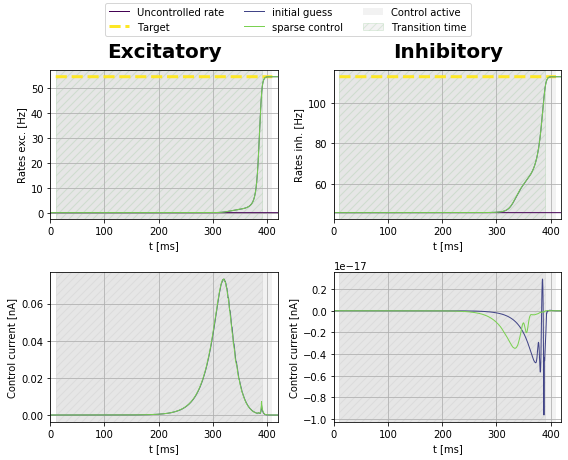

65


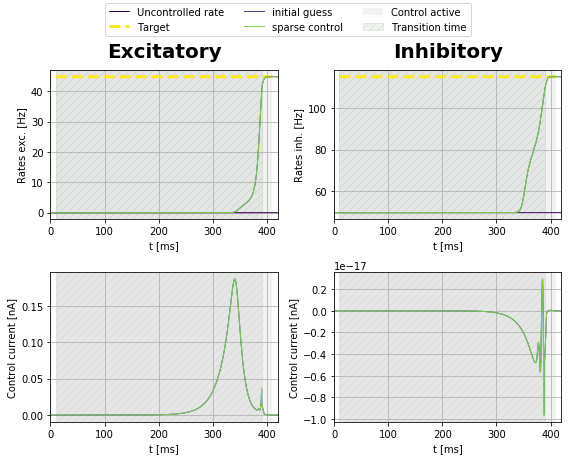

70


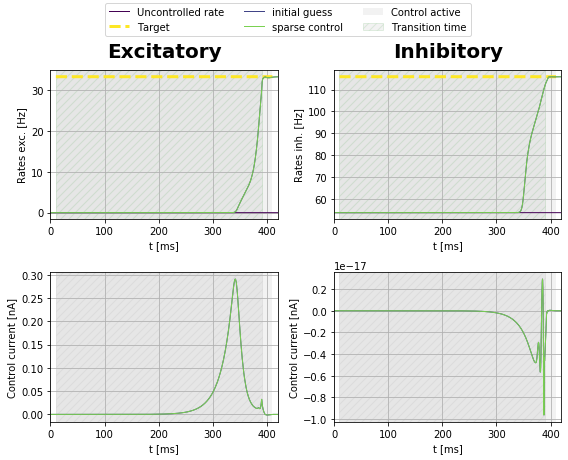

75


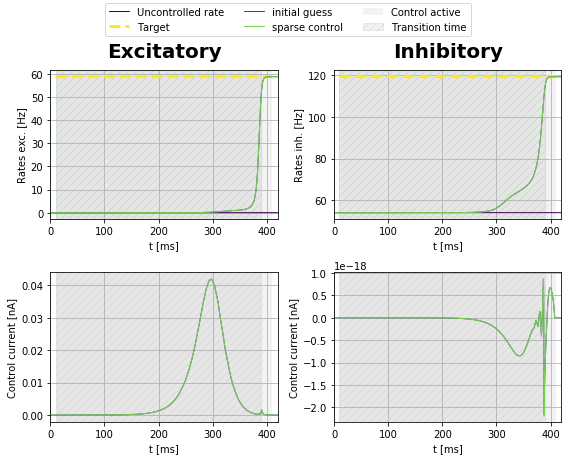

80


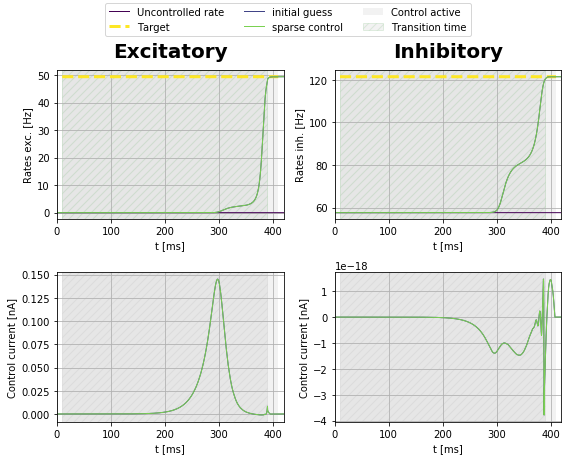

85


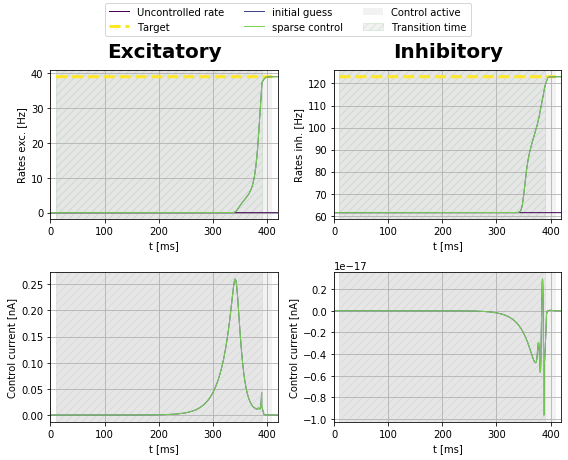

90


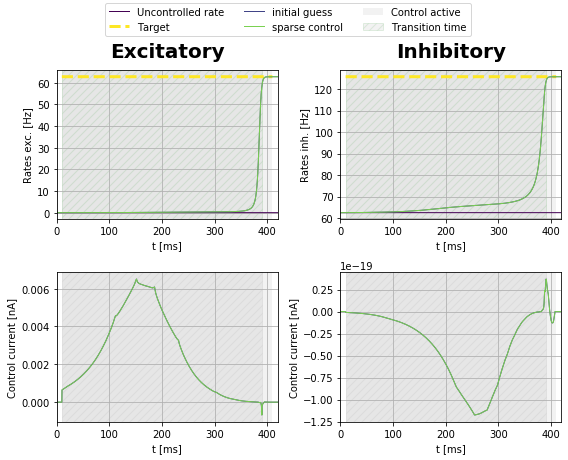

95


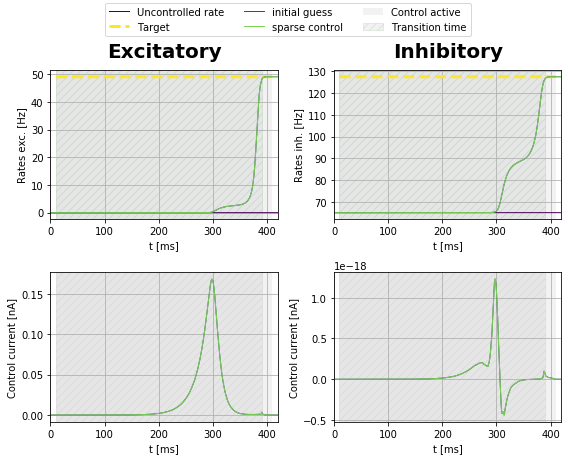

100


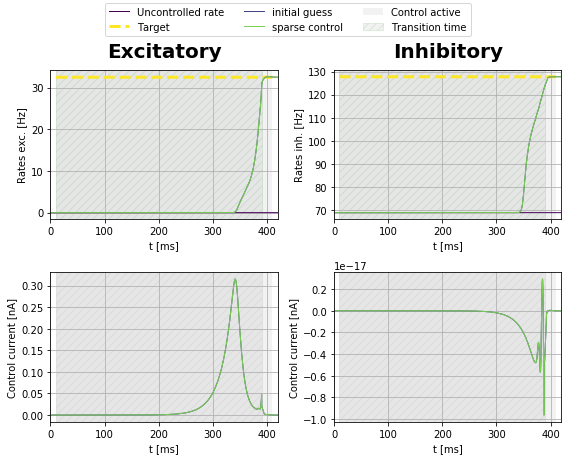

105


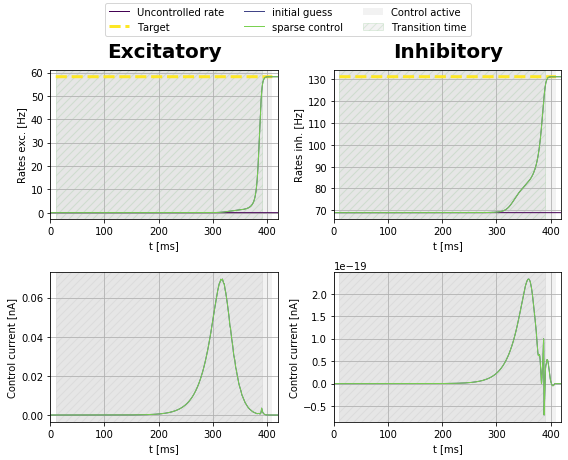

110


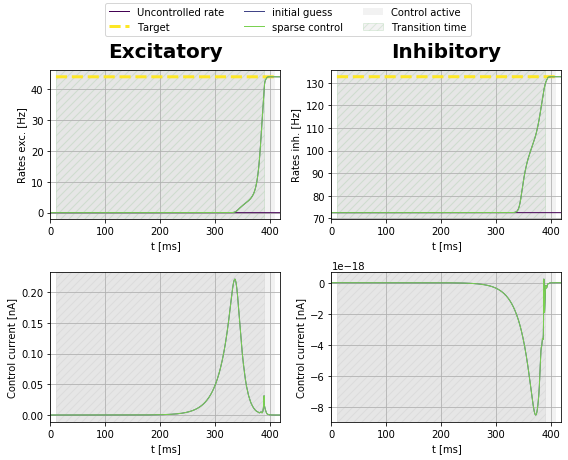

115


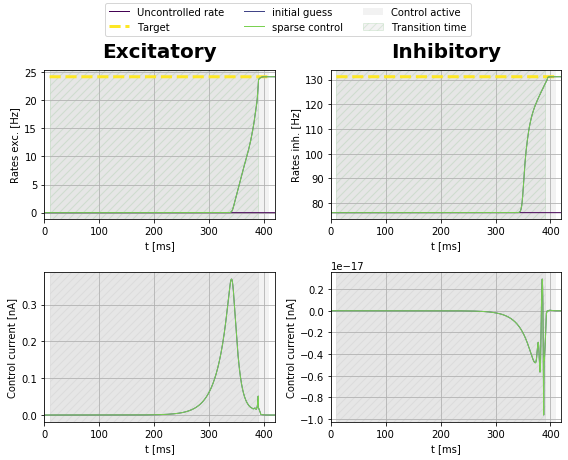

120


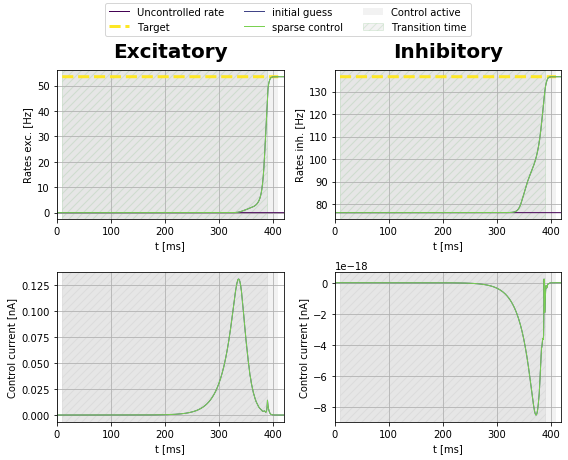

125


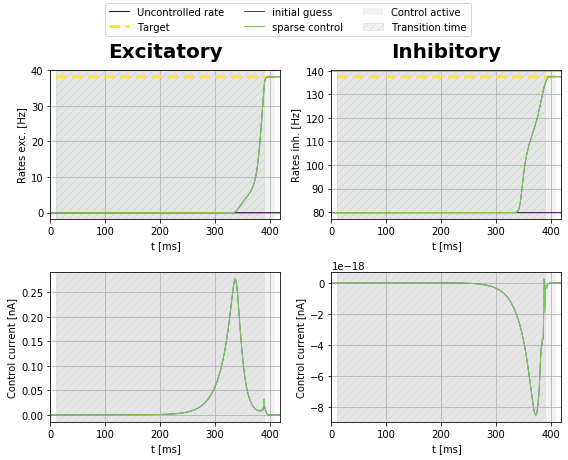

130


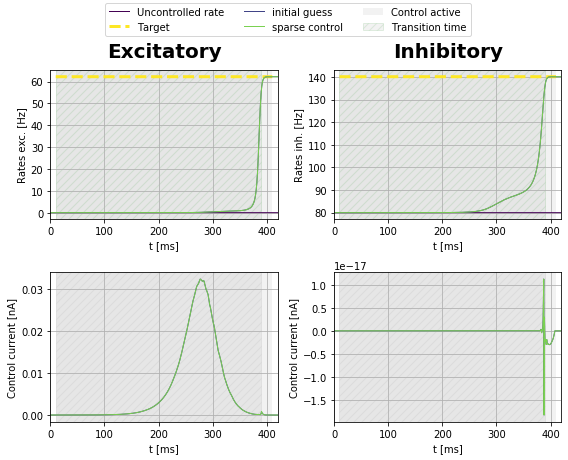

135


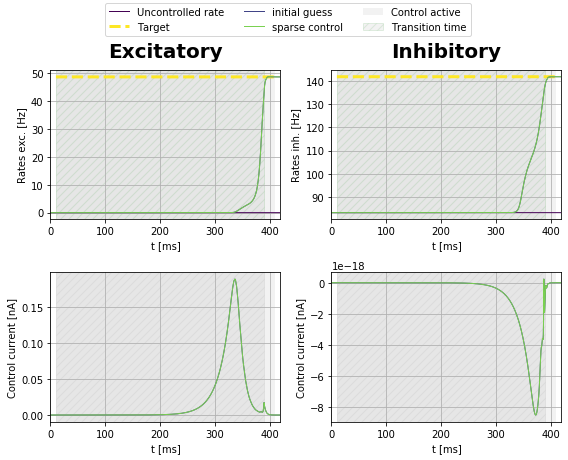

140


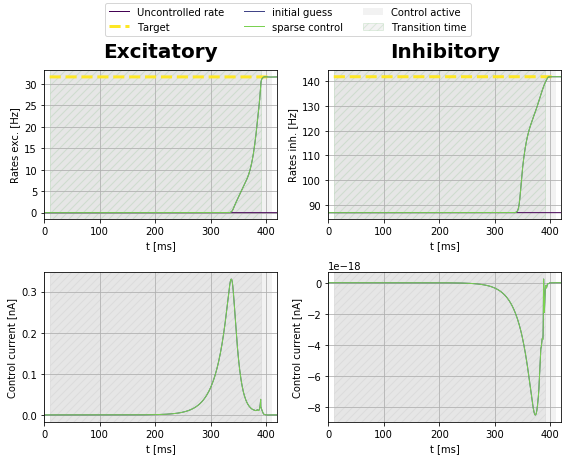

145


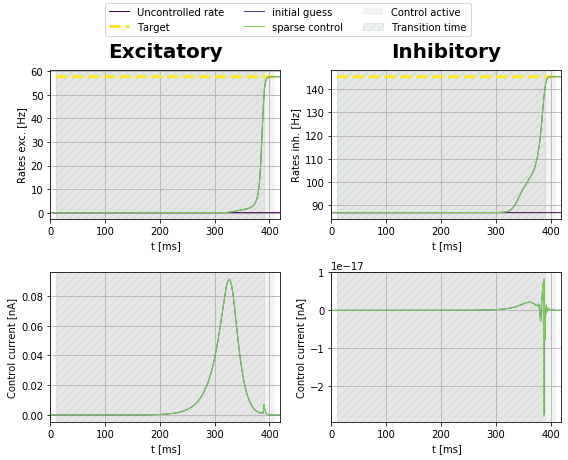

In [4]:
initVars_1, target_1 = set_target_init(exc_1, inh_1, max_I, aln, dur)

path1 = path_directory + os.sep + '1'
print(path1)

try:
    os.stat(path1)
except:
    os.mkdir(path1) 

for i in range(len(exc_1)):
        
    file_ = str(i)
    aln.params.mue_ext_mean = exc_1[i] * 5.
    aln.params.mui_ext_mean = inh_1[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in exc_:
            #print(i, j)
            if exc_1[i] == ext_exc[j] and inh_1[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_1[i], target_1[i], path1, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)
    plt.show()

D:\Promotion\neurolib\GUI\current\gui\plots_\00121\2
0
5
10
15
20
25
30
40
50


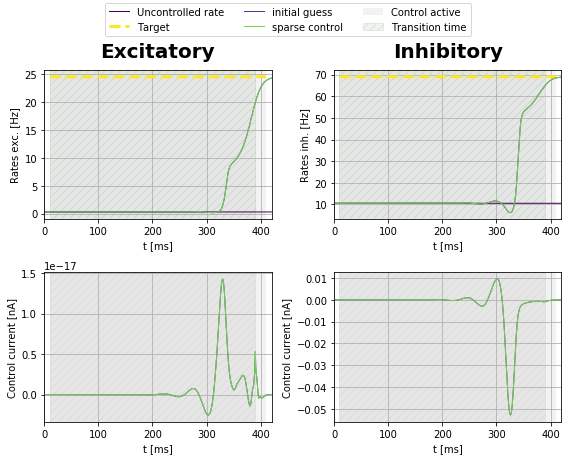

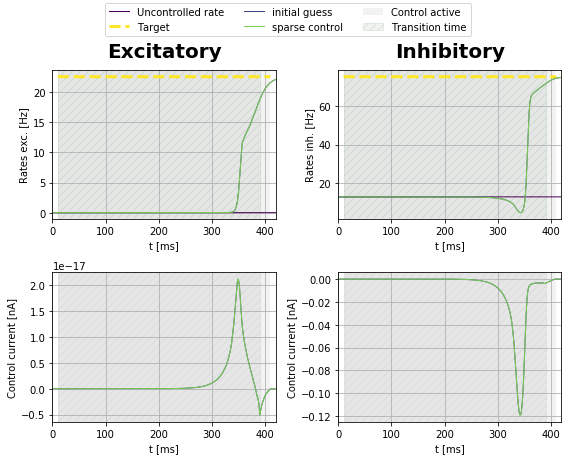

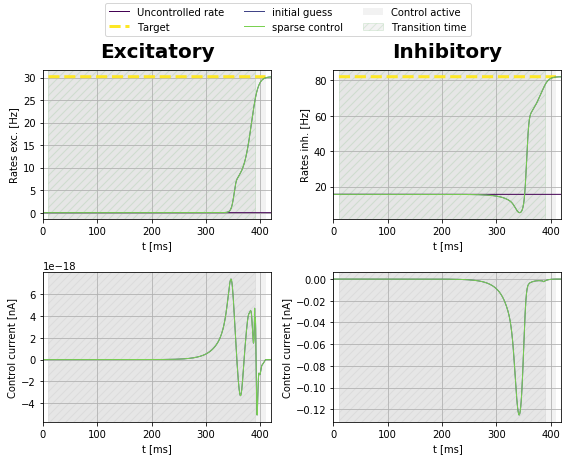

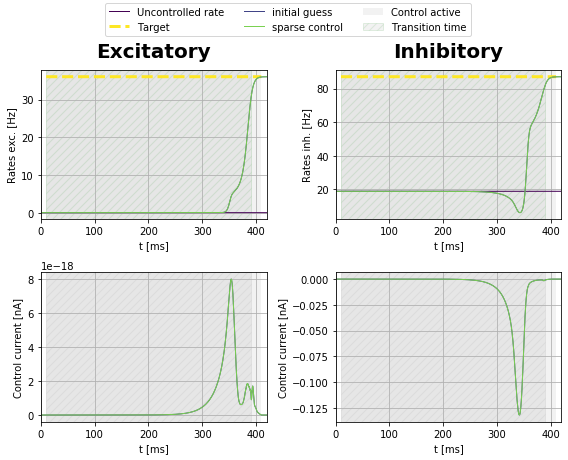

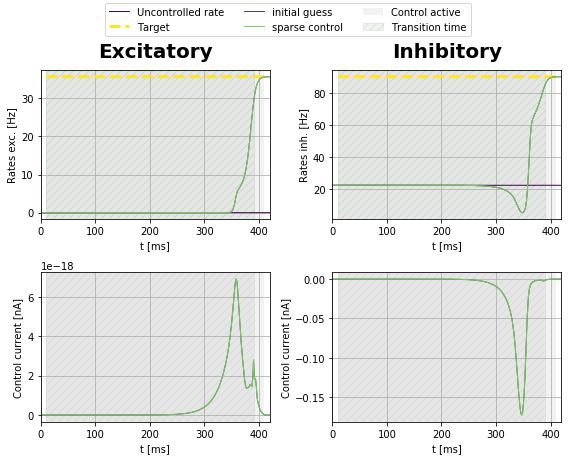

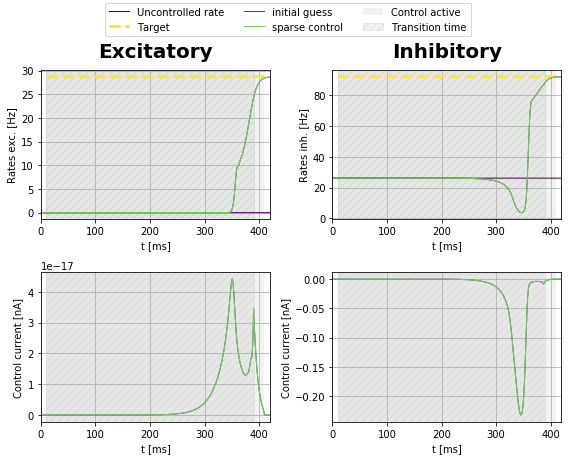

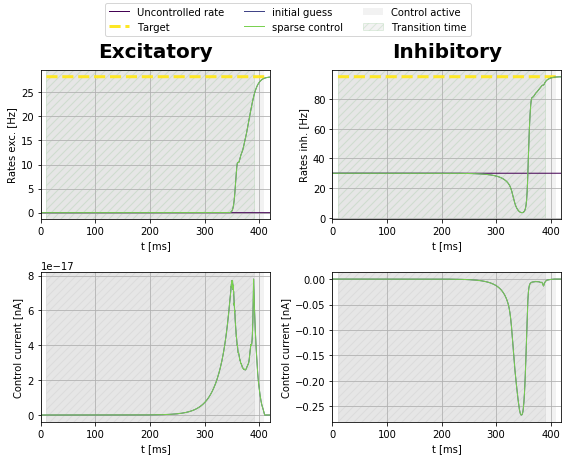

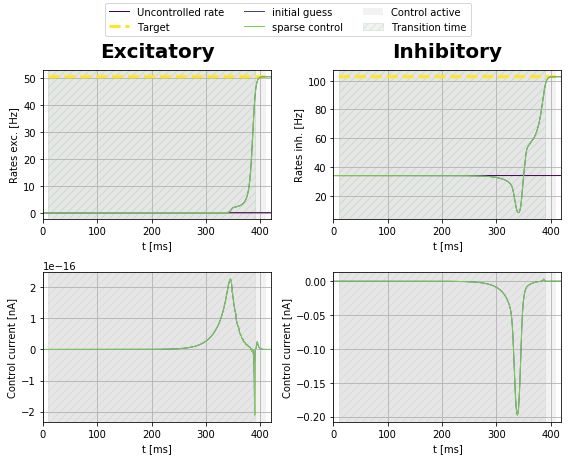

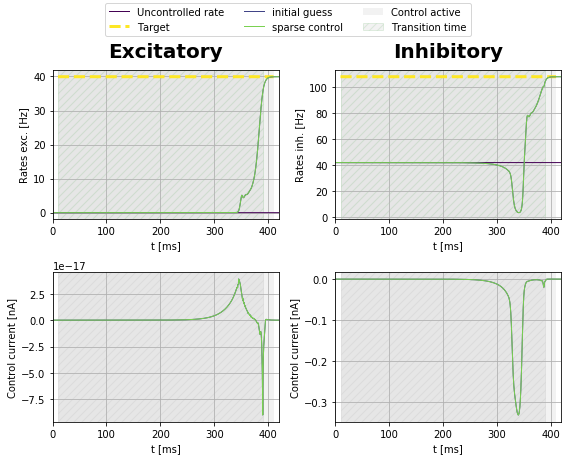

In [5]:
initVars_2, target_2 = set_target_init(exc_2, inh_2, max_I, aln, dur)

path2 = path_directory + os.sep + '2'
print(path2)

try:
    os.stat(path2)
except:
    os.mkdir(path2) 

for i in range(len(exc_2)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_2[i] * 5.
    aln.params.mui_ext_mean = inh_2[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in inh_:
            #print(i, j)
            if exc_2[i] == ext_exc[j] and inh_2[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_2[i], target_2[i], path2, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

In [6]:
initVars_3, target_3 = set_target_init(exc_3, inh_3, max_I, aln, dur)

path3 = path_directory + os.sep + '3'
print(path3)

try:
    os.stat(path3)
except:
    os.mkdir(path3) 

for i in range(len(exc_3)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_3[i] * 5.
    aln.params.mui_ext_mean = inh_3[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in both_c_:
            if exc_3[i] == ext_exc[j] and inh_3[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_3[i], target_3[i], path3, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

D:\Promotion\neurolib\GUI\current\gui\plots_\00121\3


In [7]:
initVars_4, target_4 = set_target_init(exc_4, inh_4, max_I, aln, dur)

path4 = path_directory + os.sep + '4'
print(path4)

try:
    os.stat(path1)
except:
    os.mkdir(path1) 

for i in range(len(exc_4)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_4[i] * 5.
    aln.params.mui_ext_mean = inh_4[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in no_c_:
            if exc_4[i] == ext_exc[j] and inh_4[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_4[i], target_4[i], path4, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)
    plt.show()

D:\Promotion\neurolib\GUI\current\gui\plots_\00121\4


In [9]:
path = os.getcwd()
case = path.split(os.sep)[-1]
print(path, case)

case1 = case[0] + case[1] + '0' + case[3] + case[4]

data_array = data.read_data(aln, path, case1)
exc_, inh_, both_c_, no_c_ = data_array[0:4]
exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

print(exc_)
print(inh_)

print(both_c_)
print(no_c_)

[bestControl_init, costnode_init, bestControl_0, bestState_0, costnode_0] = data.read_control(path, case1)

path_directory = path.split(os.sep + 'data')[0] + os.sep + 'plots_' 
path_directory = path_directory + os.sep + case1
try:
    os.stat(path_directory)
except:
    os.mkdir(path_directory)
    
cases_ = ['1', '2', '3', '4']
for c_dir in cases_:
    cases_dir = os.path.join(path_directory, c_dir)
    try:
        os.stat(cases_dir)
    except:
        os.mkdir(cases_dir)

D:\Promotion\neurolib\GUI\current\gui\data\10100 10100
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145]
[]
[]
[]


D:\Promotion\neurolib\GUI\current\gui\plots_\00000\1
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100
105
110
115


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:543: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


120


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:543: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


125


...

D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:543: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


140


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:543: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


145


D:\Promotion\neurolib\neurolib\utils\plotFunctions.py:543: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(rows, columns, figsize=(8, 6) )#, linewidth=8, edgecolor='grey')


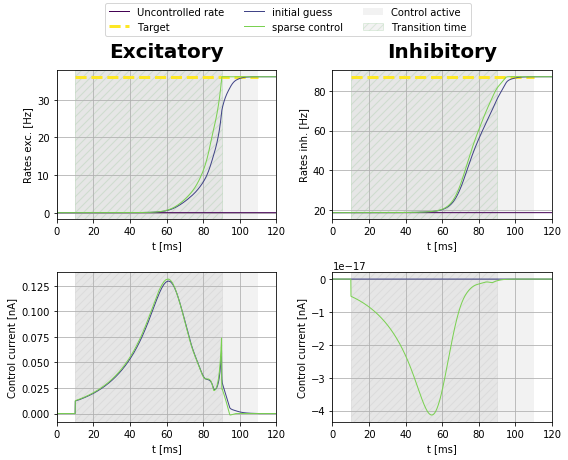

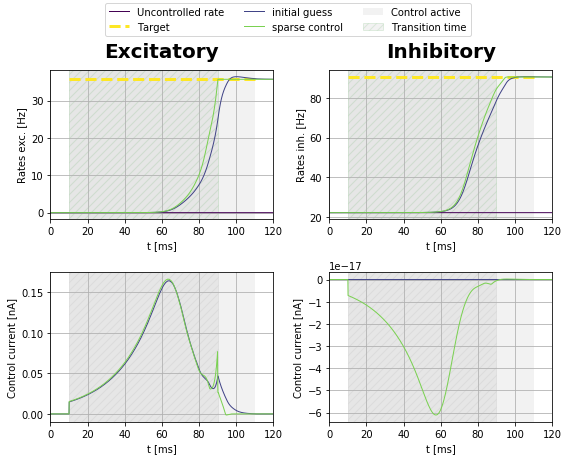

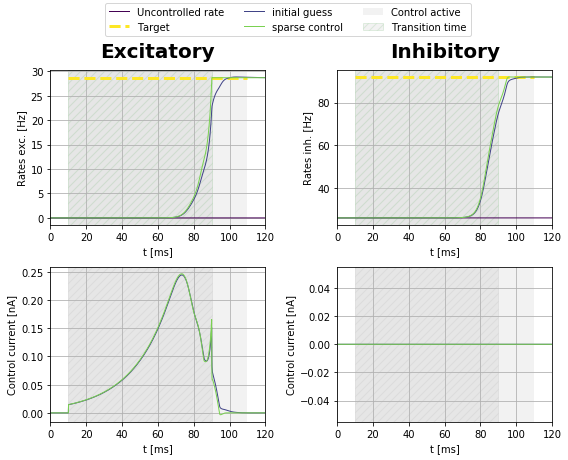

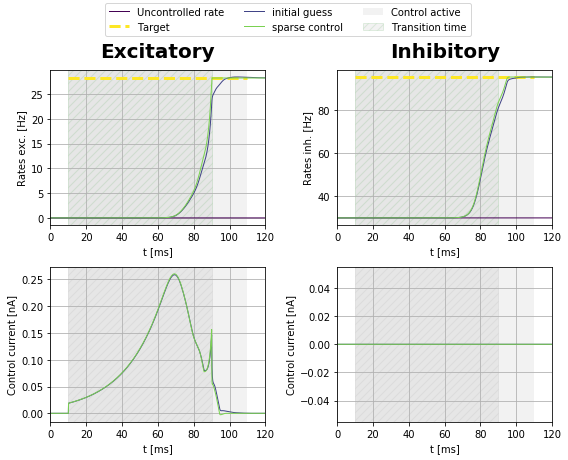

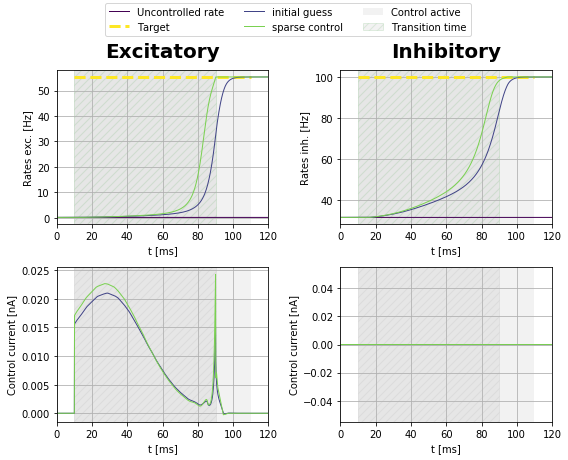

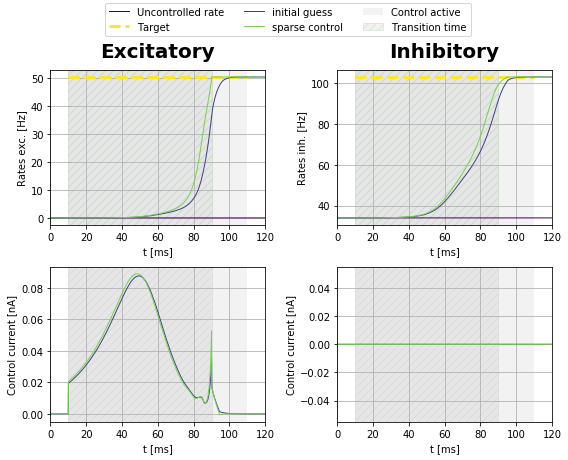

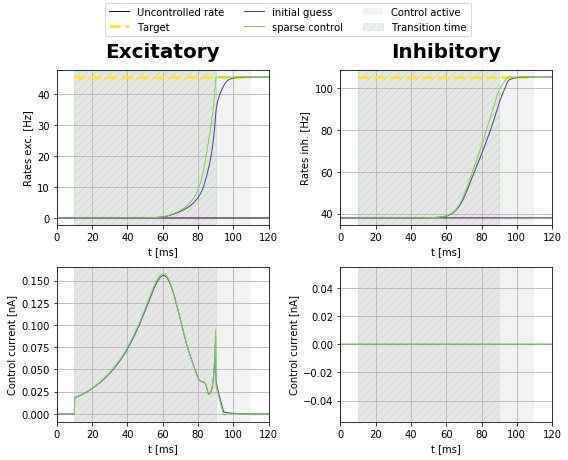

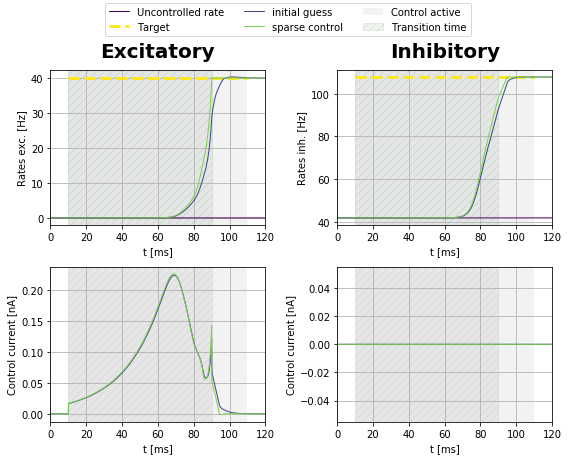

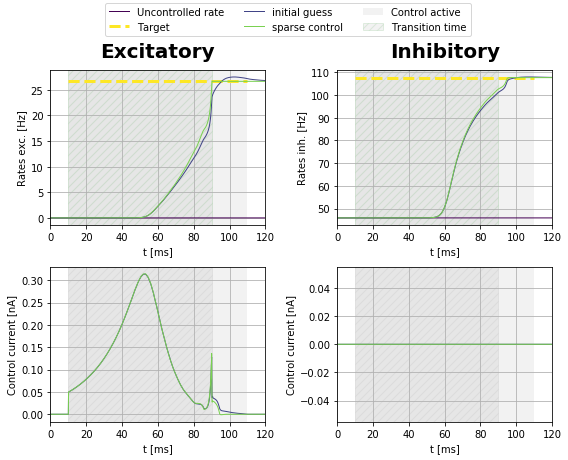

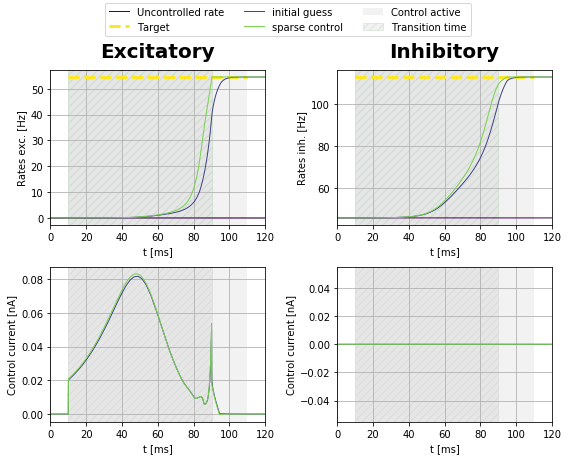

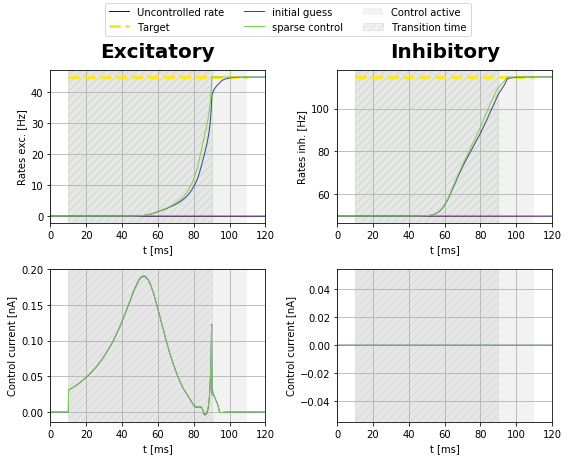

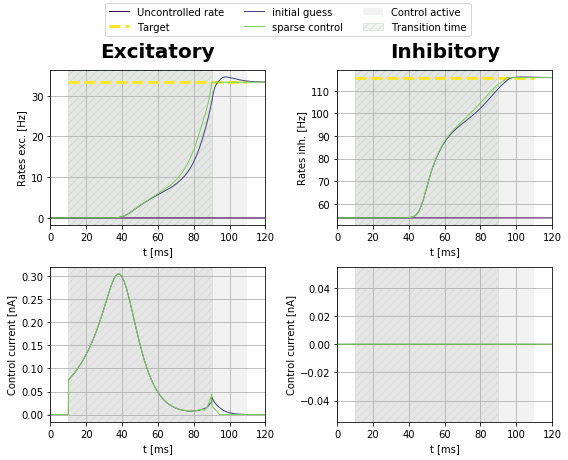

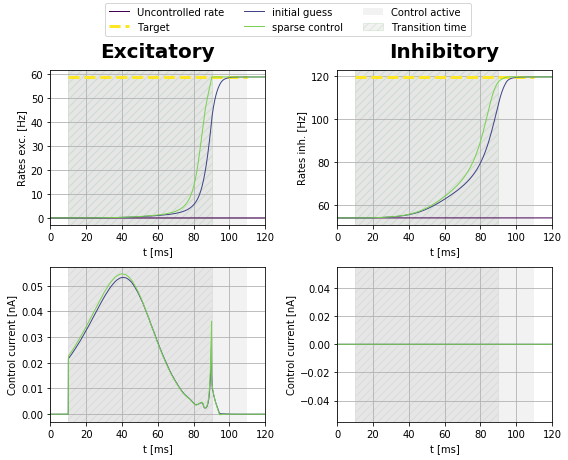

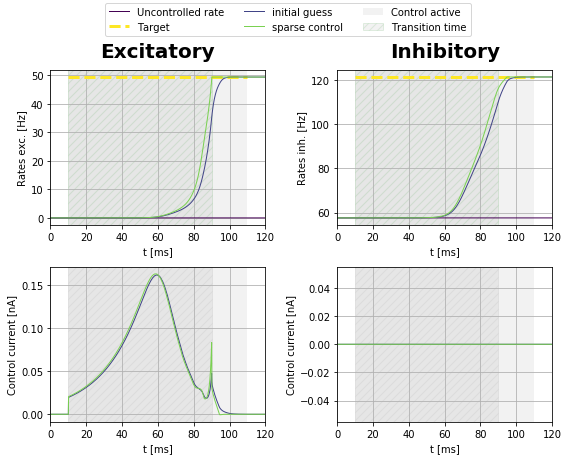

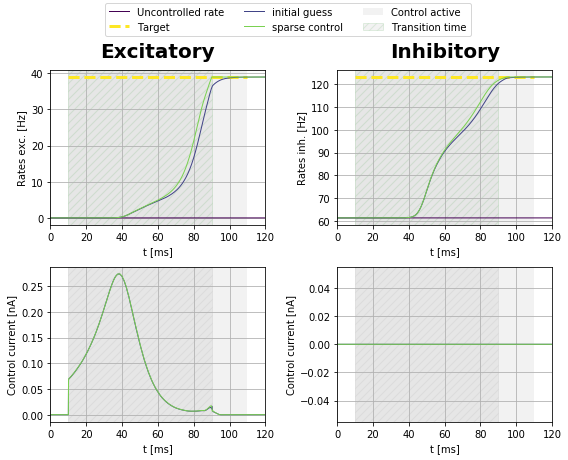

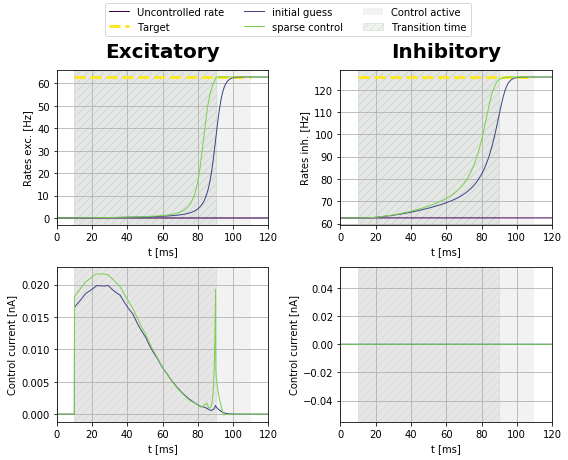

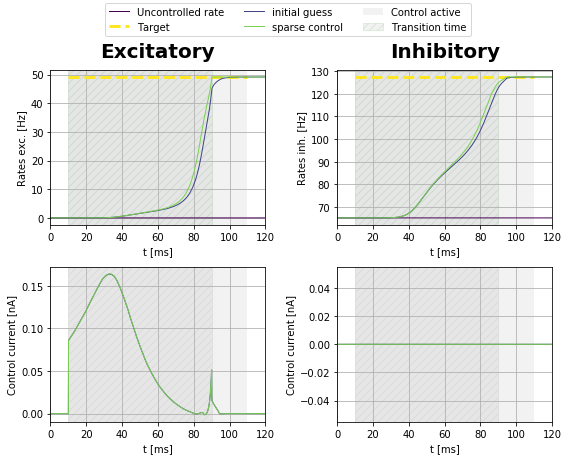

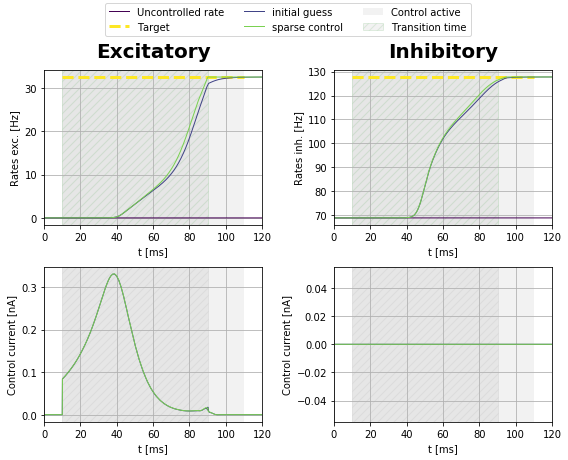

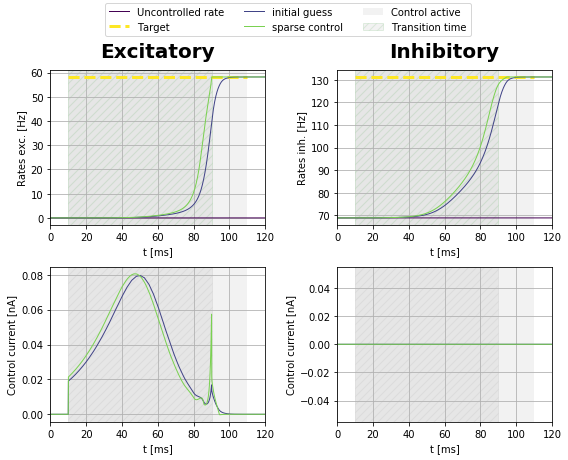

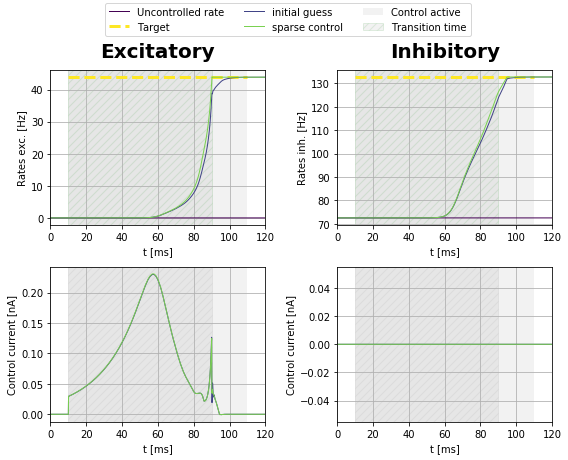

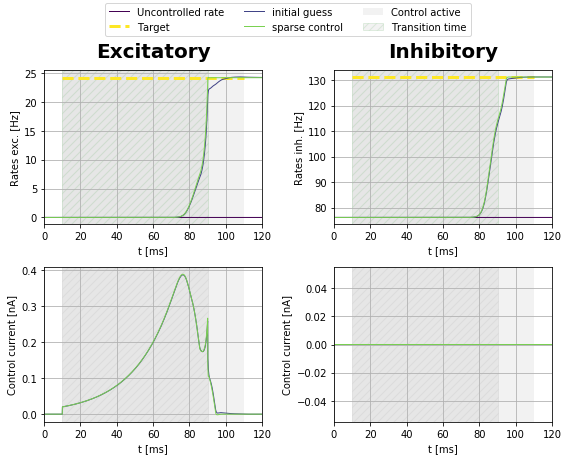

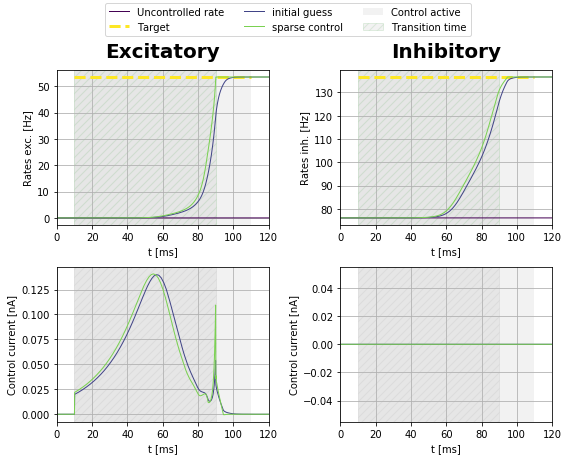

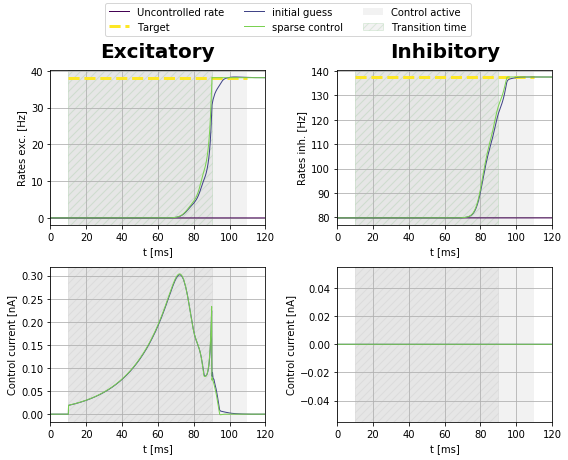

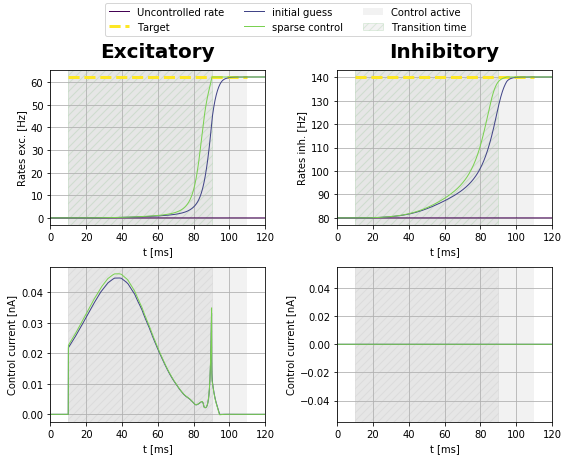

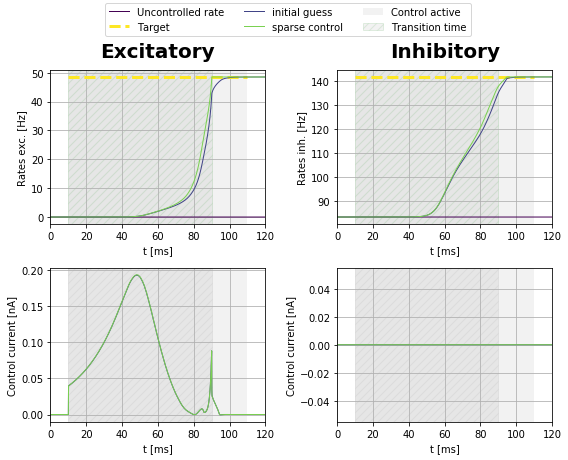

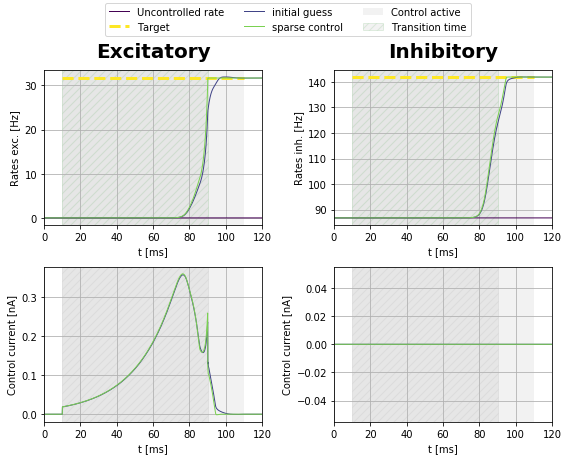

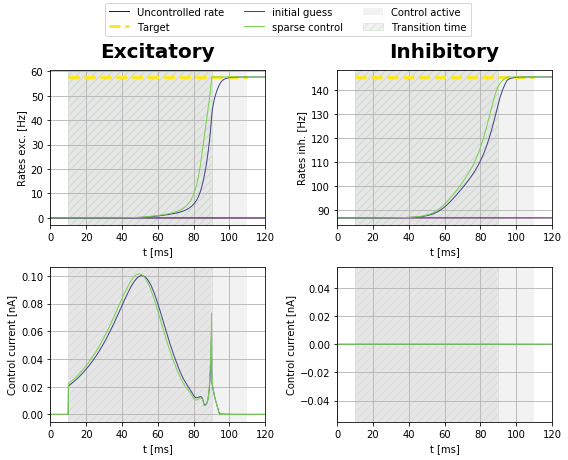

In [16]:
initVars_1, target_1 = set_target_init(exc_1, inh_1, max_I, aln, dur)

path1 = path_directory + os.sep + '1'
print(path1)

try:
    os.stat(path1)
except:
    os.mkdir(path1) 

for i in range(len(exc_1)):
        
    file_ = str(i)
    aln.params.mue_ext_mean = exc_1[i] * 5.
    aln.params.mui_ext_mean = inh_1[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in exc_:
            #print(i, j)
            if exc_1[i] == ext_exc[j] and inh_1[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_1[i], target_1[i], path1, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

D:\Promotion\neurolib\GUI\current\gui\plots_\00000\2
0
5


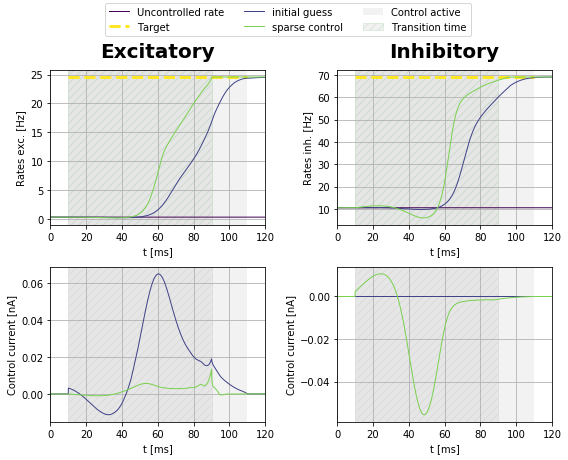

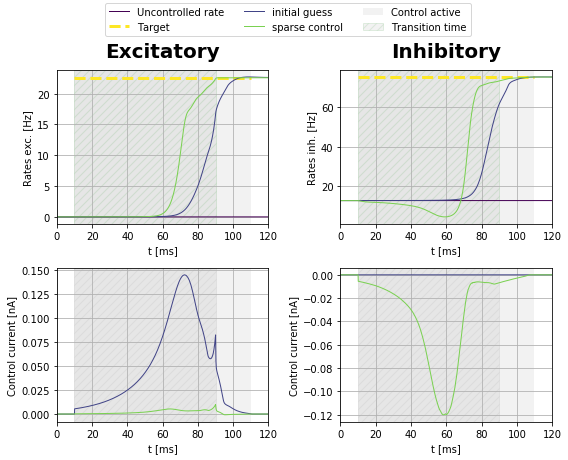

In [17]:
initVars_2, target_2 = set_target_init(exc_2, inh_2, max_I, aln, dur)

path2 = path_directory + os.sep + '2'
print(path2)

try:
    os.stat(path2)
except:
    os.mkdir(path2) 

for i in range(len(exc_2)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_2[i] * 5.
    aln.params.mui_ext_mean = inh_2[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in inh_:
            #print(i, j)
            if exc_2[i] == ext_exc[j] and inh_2[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_2[i], target_2[i], path2, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

D:\Promotion\neurolib\GUI\current\gui\plots_\00000\3
10


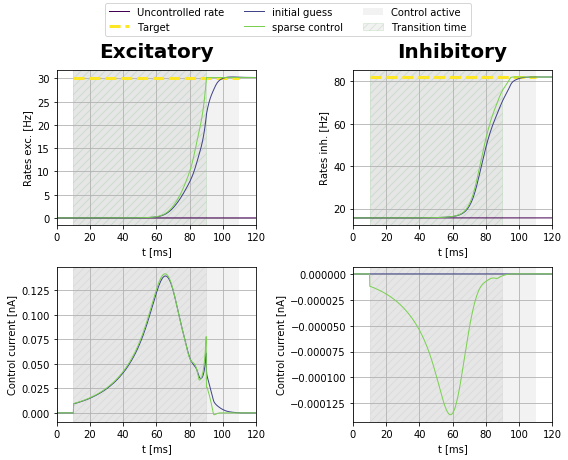

In [18]:
initVars_3, target_3 = set_target_init(exc_3, inh_3, max_I, aln, dur)

path3 = path_directory + os.sep + '3'
print(path3)

try:
    os.stat(path3)
except:
    os.mkdir(path3) 

for i in range(len(exc_3)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_3[i] * 5.
    aln.params.mui_ext_mean = inh_3[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in both_c_:
            if exc_3[i] == ext_exc[j] and inh_3[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_3[i], target_3[i], path3, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

In [19]:
initVars_4, target_4 = set_target_init(exc_4, inh_4, max_I, aln, dur)

path4 = path_directory + os.sep + '4'
print(path4)

try:
    os.stat(path1)
except:
    os.mkdir(path1) 

for i in range(len(exc_4)):
    file_ = str(i)
    aln.params.mue_ext_mean = exc_4[i] * 5.
    aln.params.mui_ext_mean = inh_4[i] * 5.
    
    for j in range(len(ext_exc)):
        if j in no_c_:
            print(i, j)
            if exc_4[i] == ext_exc[j] and inh_4[i] ==  ext_inh[j]:
                index_ = j
                print(j)
                break
                
    print(np.amin(bestControl_0[index_][0,1,:]), np.amax(bestControl_0[index_][0,1,:]))
    
    plotFunc.plot_control_current(aln, [bestControl_init[index_], bestControl_0[index_]],
        [costnode_init[index_], costnode_0[index_]], [[1.,0.,1.], [1.,0.,1.]], dur,
        dur_pre, dur_post, initVars_4[i], target_4[i], path4, filename_ = file_, transition_time_ = trans_time,
        labels_ = ["initial guess", "sparse control"], print_cost_=False)

D:\Promotion\neurolib\GUI\current\gui\plots_\00000\4
